In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve
)

In [31]:
path = "Desktop/LEARNDEPTH/Learn_depth_Project_2/datasets/dataset_04_ecommerce_purchase_intent.csv"
df = pd.read_csv(path)
print(df)

     pages_viewed  session_minutes  products_viewed  cart_additions  \
0              27            24.79                3               5   
1              54            13.29                2               5   
2              45             2.00                5               2   
3              50            50.66                5               6   
4              34            43.77                2               3   
..            ...              ...              ...             ...   
995            39            11.02                1               1   
996            61            61.20                2               2   
997            23             2.00                3               2   
998            21            44.76                4               2   
999            38            47.78                4               7   

     discount_seen  previous_orders  target  
0                3                5       0  
1                2                5       1  
2        

In [32]:
#inspection of dataset
df.shape

(1000, 7)

In [33]:
df.describe()

,pages_viewed,session_minutes,products_viewed,cart_additions,discount_seen,previous_orders,target
count,1000.00000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,40.79200,36.405290,2.922000,2.94100,2.913000,3.024000,0.50000
std,13.90403,18.669218,1.735202,1.71536,1.684716,1.733906,0.50025
min,18.00000,2.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,29.00000,23.030000,2.000000,2.00000,2.000000,2.000000,0.00000
50%,40.00000,36.705000,3.000000,3.00000,3.000000,3.000000,0.50000
75%,53.00000,49.607500,4.000000,4.00000,4.000000,4.000000,1.00000
max,65.00000,99.350000,10.000000,10.00000,9.000000,9.000000,1.00000


In [34]:
df.isna().sum()

pages_viewed       0
session_minutes    0
products_viewed    0
cart_additions     0
discount_seen      0
previous_orders    0
target             0
dtype: int64

In [35]:
df.duplicated().sum()

np.int64(0)

In [36]:
print(df["target"].value_counts(normalize=True) * 100)

target
0    50.0
1    50.0
Name: proportion, dtype: float64


In [37]:
#SEPARATE FEATURES AND TARGET 
X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures:")
print(X.columns.tolist())


Features:
['pages_viewed', 'session_minutes', 'products_viewed', 'cart_additions', 'discount_seen', 'previous_orders']


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining shape:", X_train.shape)
print("Testing shape:", X_test.shape)


Training shape: (800, 6)
Testing shape: (200, 6)


In [39]:
#BUILD PIPELINE & standardization
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("logistic_regression", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

In [40]:
#TRAIN MODEL
model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('logistic_regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalti

In [41]:
#PREDICTIONS
y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)[:, 1]

In [43]:
#MODEL EVALUATION
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_probability)

print("\nMODEL PERFORMANCE")
print("-----------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", auc)


MODEL PERFORMANCE
-----------------
Accuracy : 0.73
Precision: 0.7395833333333334
Recall   : 0.71
F1-score : 0.7244897959183674
ROC-AUC  : 0.8005


In [44]:
#CLASSIFICATION REPORT

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.75      0.74       100
           1       0.74      0.71      0.72       100

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200




Confusion Matrix:
[[75 25]
 [29 71]]


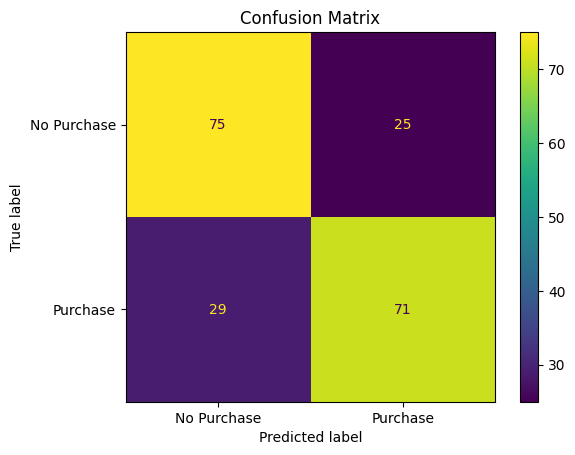

In [45]:
# CONFUSION MATRIX

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Purchase", "Purchase"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()


In [46]:
# COEFFICIENTS

coefficients = model.named_steps[
    "logistic_regression"
].coef_[0]

coefficient_table = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": coefficients,
    "Odds_Ratio": np.exp(coefficients)
})

coefficient_table = coefficient_table.sort_values(
    "Coefficient",
    ascending=False
)

print("\nLogistic Regression Coefficients:")
print(coefficient_table)



Logistic Regression Coefficients:
           Feature  Coefficient  Odds_Ratio
4    discount_seen     0.652460    1.920259
0     pages_viewed     0.636711    1.890253
2  products_viewed     0.612081    1.844266
1  session_minutes    -0.336610    0.714187
3   cart_additions    -0.341428    0.710755
5  previous_orders    -0.394278    0.674166


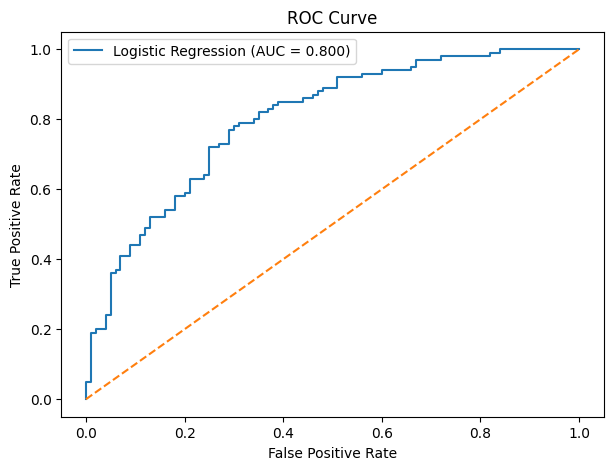

In [47]:
# ROC CURVE

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()


In [48]:
#  PREDICT A NEW WEBSITE SESSION

new_session = pd.DataFrame({
    "pages_viewed": [8],
    "session_minutes": [12],
    "products_viewed": [5],
    "cart_additions": [2],
    "discount_seen": [3],
    "previous_orders": [1]
})

prediction = model.predict(new_session)

purchase_probability = model.predict_proba(
    new_session
)[0, 1]

print("\nNEW SESSION PREDICTION")
print("---------------------")
print("Purchase probability:",
      purchase_probability)

if prediction[0] == 1:
    print("Prediction: PURCHASE")
else:
    print("Prediction: NO PURCHASE")


NEW SESSION PREDICTION
---------------------
Purchase probability: 0.5772803951711923
Prediction: PURCHASE
